<a href="https://colab.research.google.com/github/febyataalya/PCVK-Ganjil-2026/blob/main/Week5_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

**E-1 PERCOBAAN HISTOGRAM**

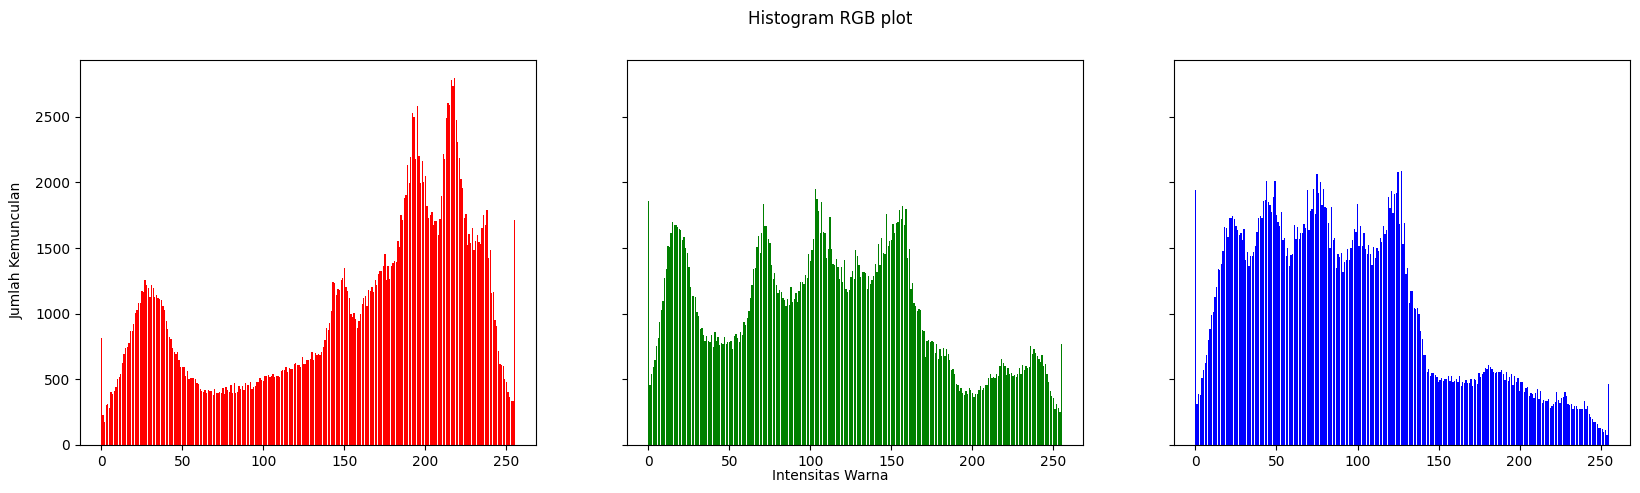

In [8]:
img = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height) :
    for x in range(0, width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

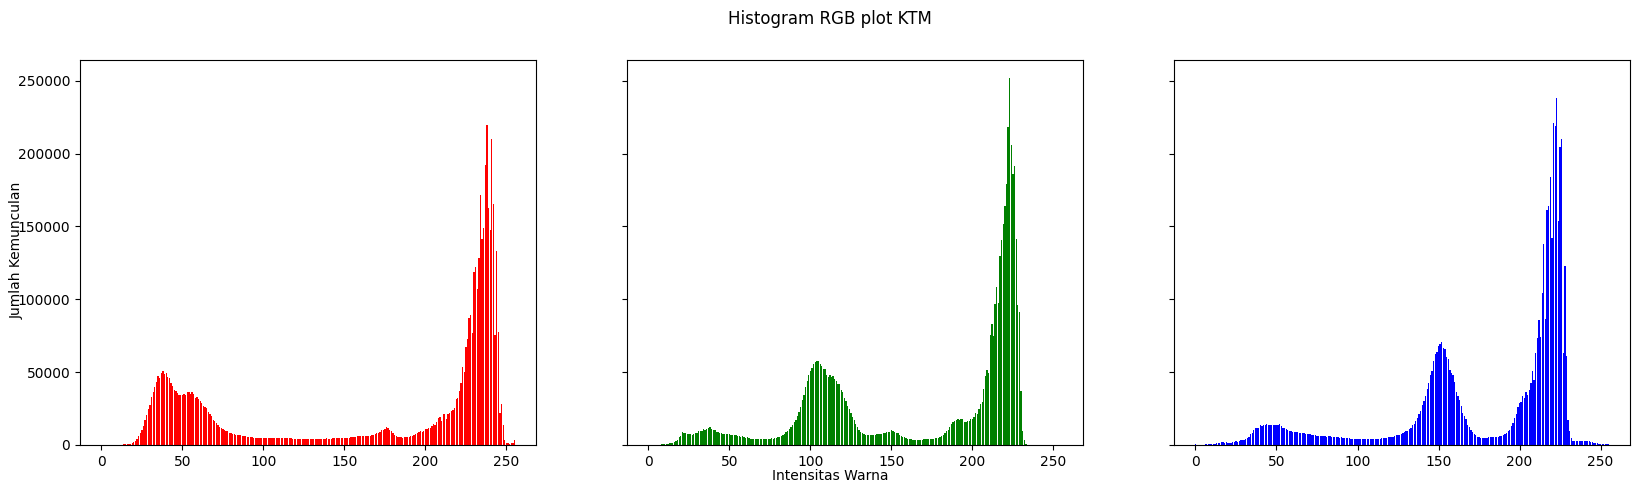

In [9]:
img = cv.imread('/content/drive/MyDrive/PCVK 2026/ktm.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height) :
    for x in range(0, width) :
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot KTM')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

**PERTANYAAN PRAKTIKUM E1**

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

[lena.jpg] Selisih maks Manual dan NumPy: 0 | Manual dan OpenCV: 0


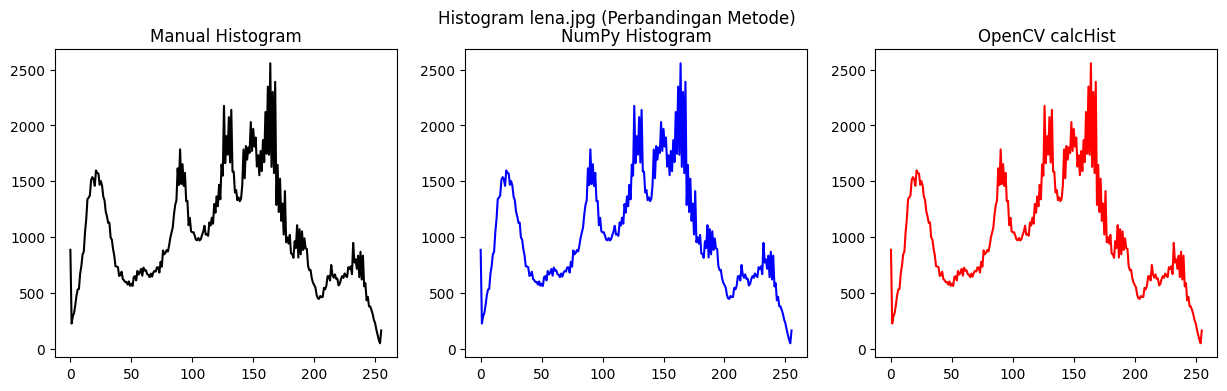

[KTM1b.jpg] Selisih maks Manual dan NumPy: 0 | Manual dan OpenCV: 0


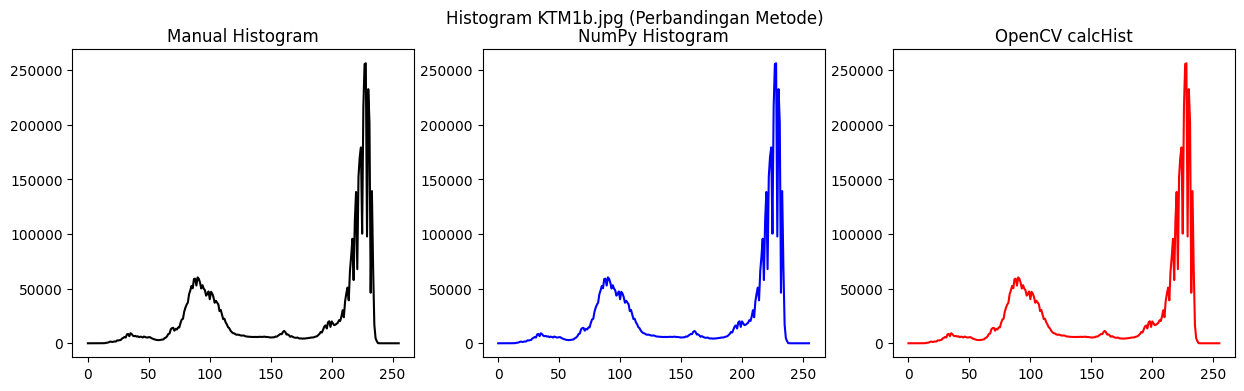

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

gray_lena = cv.imread('/content/drive/MyDrive/PCVK 2026/Images/lena.jpg', cv.IMREAD_GRAYSCALE)

h_manual_lena = np.zeros(256, dtype=np.int64)
for y in range(gray_lena.shape[0]):
    for x in range(gray_lena.shape[1]):
        h_manual_lena[gray_lena[y, x]] += 1

h_np_lena, bins_lena = np.histogram(gray_lena.ravel(), bins=256, range=[0, 256])

h_cv_lena = cv.calcHist([gray_lena], [0], None, [256], [0, 256]).flatten().astype(np.int64)

selisih_np_lena = np.max(np.abs(h_manual_lena - h_np_lena))
selisih_cv_lena = np.max(np.abs(h_manual_lena - h_cv_lena))

print(f"[lena.jpg] Selisih maks Manual dan NumPy: {selisih_np_lena} | Manual dan OpenCV: {selisih_cv_lena}")

plt.figure(figsize=(15, 4))
plt.suptitle("Histogram lena.jpg (Perbandingan Metode)")
plt.subplot(1, 3, 1)
plt.plot(h_manual_lena, color='black')
plt.title("Manual Histogram")

plt.subplot(1, 3, 2)
plt.plot(h_np_lena, color='blue')
plt.title("NumPy Histogram")

plt.subplot(1, 3, 3)
plt.plot(h_cv_lena, color='red')
plt.title("OpenCV calcHist")
plt.show()

# 2. KTM.JPG
gray_ktm = cv.imread('//content/drive/MyDrive/PCVK 2026/ktm.jpeg', cv.IMREAD_GRAYSCALE)

h_manual_ktm = np.zeros(256, dtype=np.int64)
for y in range(gray_ktm.shape[0]):
    for x in range(gray_ktm.shape[1]):
        h_manual_ktm[gray_ktm[y, x]] += 1

h_np_ktm, bins_ktm = np.histogram(gray_ktm.ravel(), bins=256, range=[0, 256])

h_cv_ktm = cv.calcHist([gray_ktm], [0], None, [256], [0, 256]).flatten().astype(np.int64)

selisih_np_ktm = np.max(np.abs(h_manual_ktm - h_np_ktm))
selisih_cv_ktm = np.max(np.abs(h_manual_ktm - h_cv_ktm))

print(f"[KTM1b.jpg] Selisih maks Manual dan NumPy: {selisih_np_ktm} | Manual dan OpenCV: {selisih_cv_ktm}")

plt.figure(figsize=(15, 4))
plt.suptitle("Histogram KTM1b.jpg (Perbandingan Metode)")
plt.subplot(1, 3, 1)
plt.plot(h_manual_ktm, color='black')
plt.title("Manual Histogram")

plt.subplot(1, 3, 2)
plt.plot(h_np_ktm, color='blue')
plt.title("NumPy Histogram")

plt.subplot(1, 3, 3)
plt.plot(h_cv_ktm, color='red')
plt.title("OpenCV calcHist")
plt.show()

2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

Gagal baca: /content/drive/MyDrive/PCVK 2026/ktm1.jpg
Gagal baca: /content/drive/MyDrive/PCVK 2026/ktm2.jpg
Gagal baca: /content/drive/MyDrive/PCVK 2026/ktm3.jpg
Gagal baca: /content/drive/MyDrive/PCVK 2026/ktm4.jpg


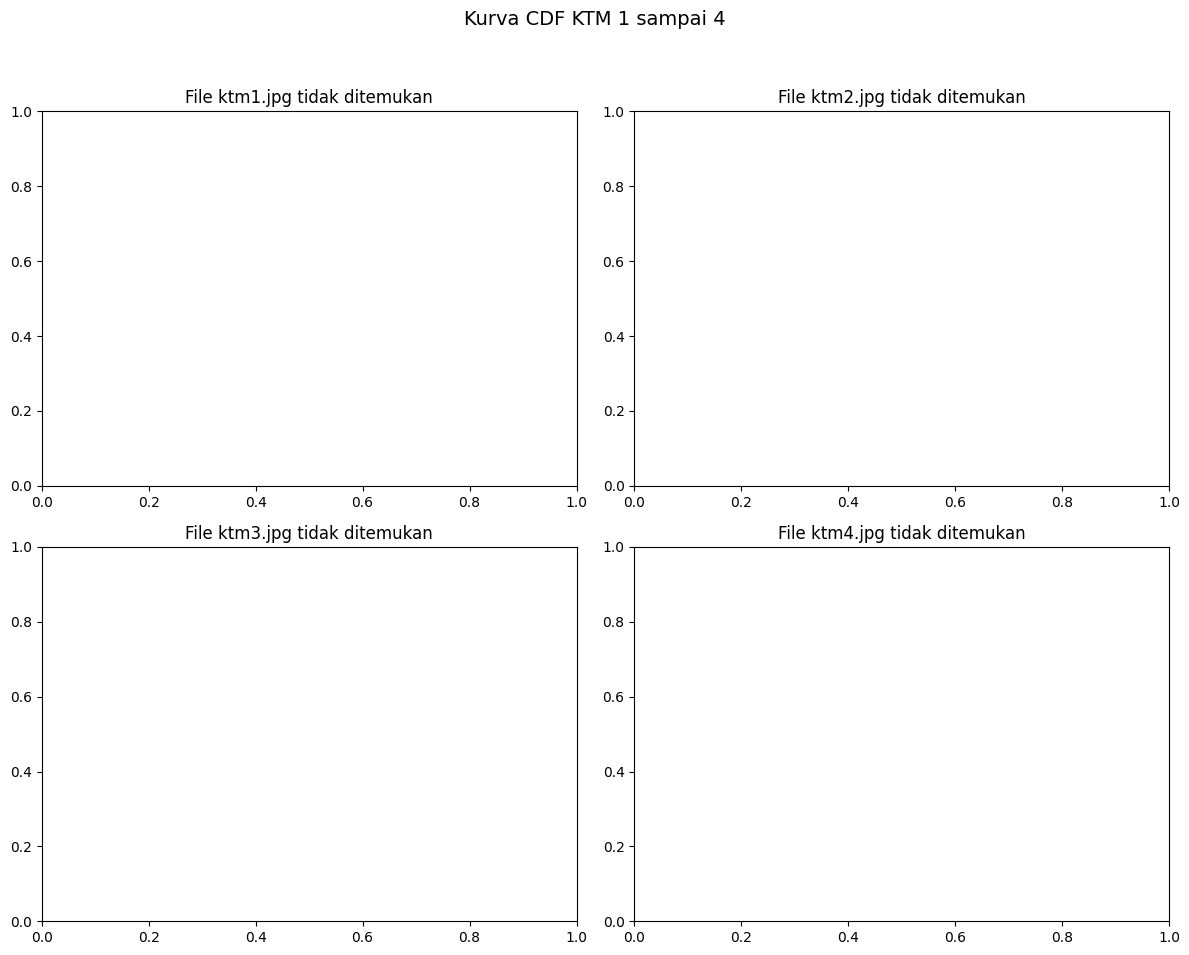

In [28]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# Tentukan folder tempat file-file itu berada di Colab
base_dir = '/content/drive/MyDrive/PCVK 2026'
ktm_files = ['ktm1.jpg', 'ktm2.jpg', 'ktm3.jpg', 'ktm4.jpg']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Kurva CDF KTM 1 sampai 4", fontsize=14)

for ax, fname in zip(axes.flatten(), ktm_files):
    # Menggabungkan folder dan nama file dengan benar
    path_file = os.path.join(base_dir, fname)
    img = cv.imread(path_file, cv.IMREAD_GRAYSCALE)

    if img is not None:
        print(f"Berhasil baca: {path_file}")
        # Hitung histogram manual
        h = np.zeros(256, dtype=np.int64)
        for y in range(img.shape[0]):
            for x in range(img.shape[1]):
                h[img[y, x]] += 1

        p = h / img.size
        cdf = np.cumsum(p)

        ax.plot(cdf, color='blue', linewidth=2)
        ax.set_title(f"CDF {fname}")
        ax.set_xlabel("Intensitas Piksel (j)")
        ax.set_ylabel("CDF")
        ax.grid(True)
    else:
        print(f"Gagal baca: {path_file}")
        ax.set_title(f"File {fname} tidak ditemukan")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [30]:
g = muat(BASE + '/content/drive/MyDrive/PCVK 2026/ktm.jpeg', gray=True)

fig, axs = plt.subplots(1, 2, figsize=(14, 4), sharey=False)
for ax, b in zip(axs, [PARAM['bins'], 256]):
    h, e = np.histogram(g, bins=b, range=(0, 256))
    ax.bar(e[:-1], h, width=256 / b, align='edge', color='gray')
    ax.set_title(NIM + ' - KTM1b, %d bin' % b, fontsize=10)
    ax.set_xlabel('intensitas'); ax.set_ylabel('jumlah piksel')
plt.show()

# bukti kuantitatif informasi yang hilang
h256 = np.bincount(g.ravel(), minlength=256)
b = PARAM['bins']; lebar = 256 // b
print('level kosong pada 256 bin :', int((h256 == 0).sum()))
print('lebar 1 bin               :', lebar, 'level intensitas')
print('puncak 256 bin di level   :', int(h256.argmax()), '| jumlah:', int(h256.max()))
hb = np.histogram(g, bins=b, range=(0, 256))[0]
print('puncak %d bin di rentang    : %d-%d | jumlah: %d' % (b, hb.argmax()*lebar, hb.argmax()*lebar + lebar - 1, hb.max()))

NameError: name 'muat' is not defined